# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Vlaura
- **Email:** vlauraagt@gmail.com
- **ID Dicoding:** CDCC009D6X1910

## Menentukan Pertanyaan Bisnis

- Pada kondisi cuaca apa rata-rata jumlah penyewaan sepeda paling tinggi dan rendah selama 2011–2012?
- Hari apa dalam seminggu yang memiliki rata-rata penyewaan tertinggi dan terendah?
- Bagaimana tren rata-rata jumlah penyewaan sepeda pada setiap bulan selama periode 2011–2012, dan pada bulan apa terjadi puncak serta penurunan terendah?
- Strategi apa yang dapat dilakukan untuk meningkatkan penyewaan pada hari dengan performa terendah berdasarkan data?

## Import Semua Packages/Library yang Digunakan

In [219]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

In [220]:
df = pd.read_csv('day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**

Dataset yang digunakan merupakan bike sharing dataset yang berisi informasi penyewaan sepeda harian selama priode 2011-2012. Dataset ini mencakup berbagai variabel penting seperti:
- Waktu (tanggal, bulan, hari)
- Faktor cuaca (suhu, kelembaban, angin, kondisi cuaca)
- Tipe pengguna (casual dan registered)
- Total penyewaan (cnt)

### Assessing Data

In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [222]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [223]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [224]:
df.duplicated().sum()

np.int64(0)

**Insight:**

Berdasarkan hasil pemeriksaan data:
- Tidak ditemukan missing value pada seluruh kolom
- Tidak ditemukan data duplikat
- kolom dteday masih bertipe object (string) dan belum dalam format datetime
- Beberapa kolom seperti season, weathersit, dan weekday masih dalam bentuk numerik (kode) sehingga kurang informatif

Jadi, dataset tergolong bersih secara struktur, namun masih perlu ditransformasi agar lebih mudah dianalisis dan divisualisasikan

### Cleaning Data

In [225]:
# konversi tipe data
df['dteday'] = pd.to_datetime(df['dteday'])

In [226]:
# hapus duplikasi
df.drop_duplicates(inplace=True)

In [227]:
# mapping kategori
df['season'] = df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

df['weathersit'] = df ['weathersit'].map({
    1: 'Clear',
    2: 'Cloudy',
    3: 'Light Rain',
})

df['weekday'] = df['weekday'].map({
    0:'Sunday',
    1:'Monday',
    2:'Tuesday',
    3:'Wednesday',
    4:'Thursday',
    5:'Friday',
    6:'Saturday'
})

df['month'] = df['mnth'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})
df['day_type'] = df['workingday'].apply(lambda x: 'Working Day' if x == 1 else 'Weekend')

**Insight:**

Beberapa langkah pembarsihan data yang dilakukan:
- Kolom dteday diubah menjadi format datetime agar dapat digunakan dalam analisis berbasis waktu
- Menghapus data yang duplikat
- Kolom season, weathersit, weekday dan month  diubah dari kode numerik menjadi label yang lebih mudah dipahami
- kolom day_type untuk membedakan antara hari kerja dan akhir pekan

Dengan ini, data menjadi lebih readable, mempermudah proses visualisasi dan mendukung analisis sesuai pertanyaan bisnis



## Exploratory Data Analysis (EDA)

### Explore ...

In [228]:
df['cnt'].describe()

,cnt
count,731.000000
mean,4504.348837
std,1937.211452
min,22.000000
25%,3152.000000
50%,4548.000000
75%,5956.000000
max,8714.000000


**Insight:**
- rata-rata penggunaan sepeda cukup tinggi, 4,5 ribu per hari
- distribusi data relatif seimbang karena median dengan mean hampir sama
- ada kondisi ekstrem dimana hampir tidak ada penyewaan, kemungkinan karena kondisi tertentu (min=22)
- ada hari dengan lonjakan demand sangat tinggi (max=8714)

<function matplotlib.pyplot.show(close=None, block=None)>

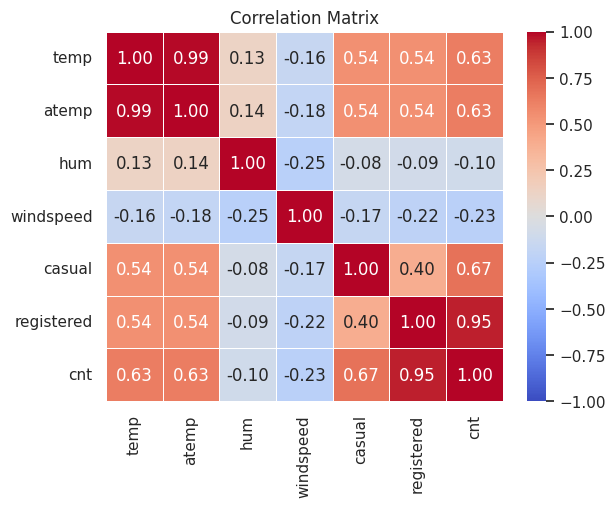

In [229]:
corr = df[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show

**Insight:**
- temp dan atemp memiliki korelasi positif yang kuat (0,63) dengan jumlah total penyewa (cnt), menunjukan bahwa semakin hangan suhu udara, semakin tinggi minat orang untuk menyewa sepeda
- variabel registered memiliki korelasi yang sangat tinggi (0,95) dengan cnt, menunjukkan bahwa pengguna utama sistem ini adalah member tetap, bukan pengguna insidental
- kecepatan angin (windspeed) dan kelembapan (hum) berkolerasi negatif dengan jumlah penyewaan. semakin tinggi kecepatan angin, semakin rendah jumlah orang yang bersepeda

In [230]:
df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)

,cnt
weathersit,
Clear,4876.786177
Cloudy,4035.862348
Light Rain,1803.285714


**Insight:**
- Kondisi Clear memiliki rata-rata penyewaan tertinggi (4,876), ini menunjukkan bahwa aktivitas bersepeda sangat bergantung pada langit yang bersih
- Terjadi penurunan lebih dari 60% pada jumlah penyewaan saat kondisi berubah dari Cloudy (4.035) ke light rain (1.803)
- Pengguna cenderung selektif, mendung tipis (Cloudy) hanya menurunkan sedikit minat, namun hujan ringan sudah cukup untuk membuat mayoritas pengguna membatalkan niat bersepeda

In [231]:
df.groupby('mnth')['cnt'].mean().sort_values(ascending=False)

,cnt
mnth,
6,5772.366667
9,5766.516667
8,5664.419355
7,5563.677419
5,5349.774194
10,5199.225806
4,4484.900000
11,4247.183333
3,3692.258065


**Insight:**
- Penyewaan sepeda paling tinggi terjadi di bulan Juni, September dan Agustus
- Puncak penggunaan ada di periode pertengahan tahun (musim panas-awal musim gugur)
- Terendah terjadi di bulan Januari, Februari dan Desember

In [232]:
df.groupby('weekday')['cnt'].mean().sort_values(ascending=False)

,cnt
weekday,
Friday,4690.288462
Thursday,4667.259615
Saturday,4550.542857
Wednesday,4548.538462
Tuesday,4510.663462
Monday,4338.123810
Sunday,4228.828571


**Insight:**
- Penyewaan di Hari kerja (weekday) lebih tinggi daripada akhir pekan, jumat dan kamis adalah puncak penggunaan
- Penyewaan di akhir pekan lebih rendah dari hari kerja

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada kondisi cuaca apa rata-rata jumlah penyewaan sepeda paling tinggi dan rendah selama 2011–2012?

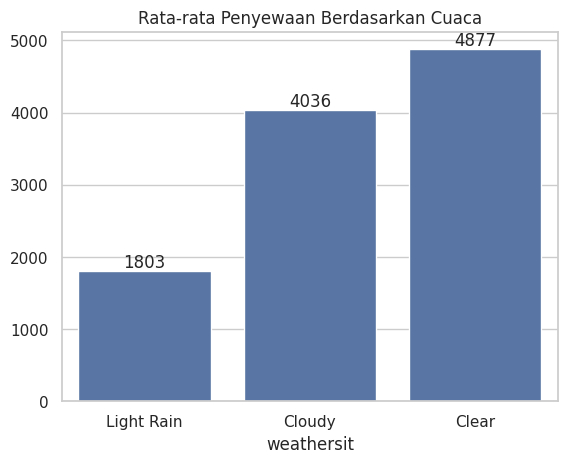

<Figure size 600x400 with 0 Axes>

In [233]:
weather_avg = df.groupby('weathersit')['cnt'].mean().sort_values()

ax=sns.barplot(x=weather_avg.index, y=weather_avg.values)
plt.title('Rata-rata Penyewaan Berdasarkan Cuaca')
plt.xlabel=('Cuaca')
plt.ylabel=('Raya-rata Penyewaan')
plt.figure(figsize=(6,4))
ax.bar_label(ax.containers[0], fmt='%.0f')
plt.show()

**Insight:**
- Kondisi dengan rata-rata penyewaan tertinggi adalah Clear (cuaca cerah) sebanyak 4877 penyewaan, artinya cuaca cerah adalah kondisi paling ideal untuk penggunaan sepeda karena mendukung aktivitas outdoor seperti commuting dan rekreasi
- Kondisi dengan rata-rata penyewaan terendah adalah Light Rain (hujan ringan) sebanyak 1803 penyewaan, menujukkan bahwa meskipun hanya hujan ringan, jumlah penyewaan sepeda turun drastis karena pengguna cenderung menghindari kondisi cuaca yan kurang nyaman

### Pertanyaan 2: Hari apa dalam seminggu yang memiliki rata-rata penyewaan tertinggi dan terendah?

<function matplotlib.pyplot.show(close=None, block=None)>

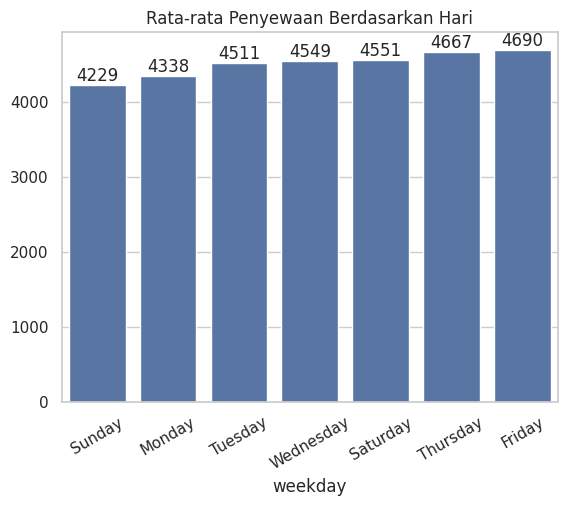

In [234]:
weekday_avg = df.groupby('weekday')['cnt'].mean().sort_values()

ax=sns.barplot(x=weekday_avg.index, y=weekday_avg.values)
plt.title('Rata-rata Penyewaan Berdasarkan Hari')
plt.xlabel=('Hari')
plt.ylabel=('Rata-rata Penyewaan')
plt.xticks(rotation=30)
ax.bar_label(ax.containers[0], fmt='%.0f')
plt.show

**Insight:**
- Hari dengan rata-rata penyewaan tertinggi adalah Friday (Jumat) dengan rata-rata 4690 penyewaan, menunjukkan bahwa menjelang akhir pekan, aktivitas pengguna meningkat (kemungkinan untuk commuting + persiapan weekend)
- Hari dengan rata-rata penyewaan terendah adalah Sunday (Minggu) dengan rata-rata 4228 penyewaan, menunjukkan bahwa penggunaan sepeda cenderung menurun di akhir pekan, kemungkinan karena aktivitas lebih santai dirumah atau tidak banyak kebutuhan commuting

### Pertanyaan 3: Bagaimana tren rata-rata jumlah penyewaan sepeda pada setiap bulan selama periode 2011–2012, dan pada bulan apa terjadi puncak serta penurunan terendah?

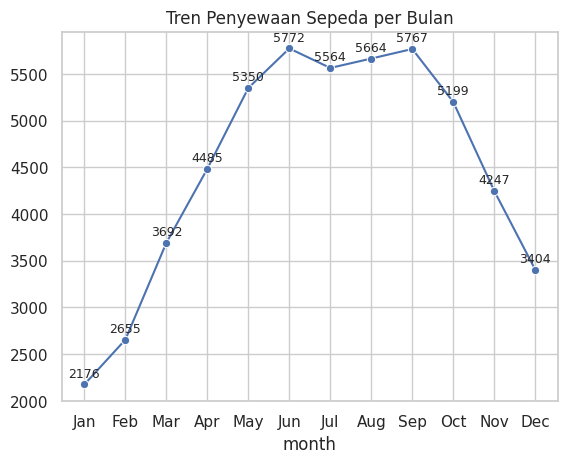

In [235]:
monthly_avg = df.groupby('month')['cnt'].mean()

order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg = monthly_avg.reindex(order)

sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o')
plt.title('Tren Penyewaan Sepeda per Bulan')
plt.xlabel=('Month')
plt.ylabel=('Rata-rata Penyewaan')
for x, y in zip(monthly_avg.index, monthly_avg.values):
    plt.text(x, y + 80, f'{y:.0f}', ha='center', fontsize=9)
plt.show()

**Insight:**
- Pola yang terbentuk adalah pola musiman (seasonal pattern) yang secara umum, pola terlihat, awal tahun (jan-feb) penyewaan terendah, lalu naik bertahap mulai maret dan puncaknya terjadi di pertengahan tahun, turun kembali menjelang akhir tahun (nov-dec)
- Bulan dengan penyewaan tertinggi adalah Juni
- Bulan dengan penyewaan terendah adalah Januari

## Analisis Lanjutan (Opsional)

# **CLUSTERING ANALYSIS**

**Clustering Berdasarkan jumlah penyewaan (Binning)**

In [236]:
df['cnt'].describe()

,cnt
count,731.000000
mean,4504.348837
std,1937.211452
min,22.000000
25%,3152.000000
50%,4548.000000
75%,5956.000000
max,8714.000000


In [237]:
df['rental_category'] = pd.cut(
    df['cnt'],
    bins=[0, 3000, 6000, 10000],
    labels=['Low', 'Medium', 'High']
)

df['rental_category'].value_counts()

,count
rental_category,
Medium,379
High,180
Low,172


**Distribusi Clustering**

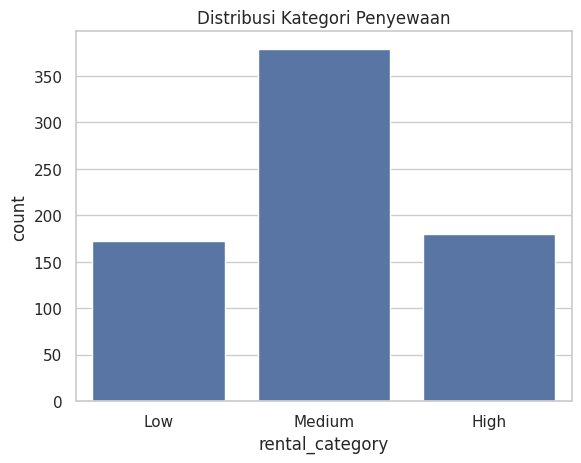

In [238]:
sns.countplot(x='rental_category', data=df)
plt.title('Distribusi Kategori Penyewaan')
plt.show()

**Hubungan Clustering dengan Cuaca**

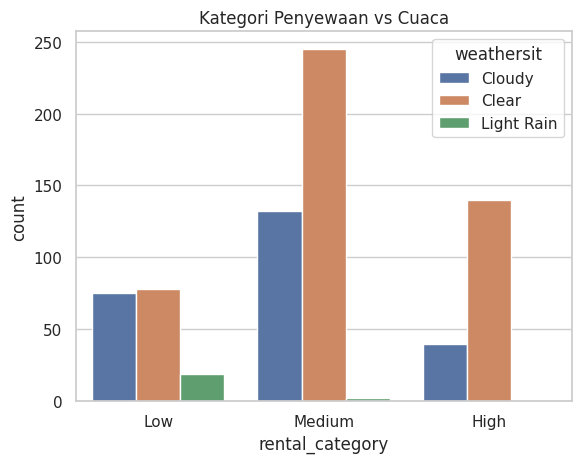

In [239]:
sns.countplot(x='rental_category', hue='weathersit', data=df)
plt.title('Kategori Penyewaan vs Cuaca')
plt.show()

**Clustering Berdasarkan suhu (Binning)**

In [240]:
df['temp'].describe()

,temp
count,731.000000
mean,0.495385
std,0.183051
min,0.059130
25%,0.337083
50%,0.498333
75%,0.655417
max,0.861667


In [241]:
df['temp_category'] = pd.cut(
    df['temp'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Cold', 'Moderate', 'Hot']
)

df.groupby('temp_category')['cnt'].mean()

/tmp/ipykernel_10739/2809136979.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('temp_category')['cnt'].mean()


,cnt
temp_category,
Cold,2381.214815
Moderate,4488.178363
Hot,5654.559055


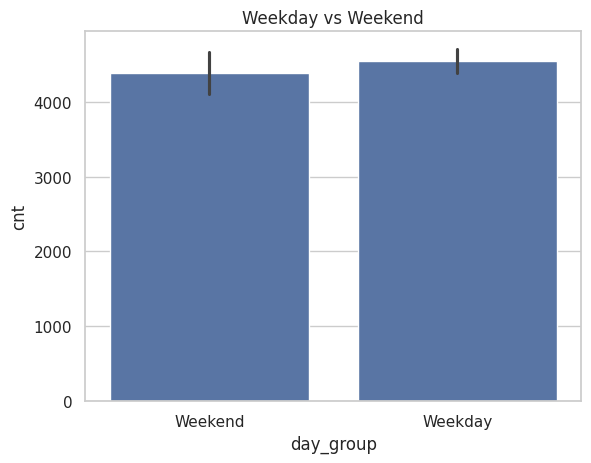

In [242]:
df['day_group'] = df['weekday'].apply(
    lambda x: 'Weekday' if x in ['Monday','Tuesday','Wednesday','Thursday','Friday']
    else 'Weekend'
)

sns.barplot(x='day_group', y='cnt', data=df)
plt.title('Weekday vs Weekend')
plt.show()

## Conclusion

- Conclution pertanyaan 1 :
Pada kondisi cuaca apa rata-rata jumlah penyewaan sepeda paling tinggi dan rendah selama 2011-2012?

Rata-rata penyewaan sepeda paling tinggi terjadi saat cuaca cerah (clear) yaitu 4876 penyewaan, dan paling rendah saat Light Rain (hujan ringan) yaitu 1803 penyewaan.

Cuaca merupakan faktor paling signifikan yang memengaruhi keputusan pengguna dalam menyewa sepeda. semakin buruk kondisi cuaca, semakin drastis penurunan jumlah penyewaan.


- Conclution pertanyaan 2 : Hari apa dalam seminggu (weekday) yang memiliki rata-rata penyewaan tertinggi dan terendah?

Rata-rata penyewaan tertinggi terjadi pada hari Jumat (4690 penyewaan), sedangkan terendah pada hari minggu (4228 penyewaan).

Penggunaan sepeda lebih dominan pada hari kerja dibanding akhir pekan, yang menunjukkan bahwa sepeda lebih banyak digunakan untuk aktivitas commuting (kerja/kuliah) dibanding rekreasi


- Conclution pertanyaan 3 : Bagaimana tren rata-rata jumlah penyewaan sepeda pada setiap bulan selama periode 2011-2012, dan pada bulan apa terjadi puncak serta penurunan terendah?

pola terlihat, awal tahun (jan-feb) penyewaan terendah sekitar (2176-2655 penyewaan), lalu naik bertahap mulai maret (3692 penyewaan) dan puncaknya terjadi di pertengahan tahun yaitu juni (5772 penyewaan), mulai turun kembali menjelang akhir tahun nov-dec sekitar (4247-3404 penyewaan)
Bulan dengan penyewaan tertinggi adalah bulan Juni (5772 penyewaan)
Bulan dengan penyewaan terendah adalah bulan Januari (2176 penyewaan)

Terdapat pola seasonality yang kuat, di mana musim panas meningkatkan permintaan secara signifikan, sedangkan musim dingin menurunkannya


- Conclution pertanyaan 4 : Strategi apa yang dapat dilakukan untuk meningkatkan penyewaan pada hari dengan performa terendah berdasarkan data weekday?

Strategi yang dapat dilakukan untuk meningkatkan penyewaan di hari dengan performa terendah berdasarkan data Sunday (minggu) dan Monday (senin) adalah dengan mengadakan promo khusus (week start/end ride) dengan memberikan diskon 10%-30% agar meningkatkan penyewaan pada hari dengan performa rendah dengan cara memanfaatkan sensitivitas harga pengguna tanpa mengubah infrastruktur operasional

In [243]:
df.to_csv('main_data.csv', index=False)

In [244]:
from google.colab import files
files.download('main_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>